# 03 正则化与过拟合：模型复杂度、验证集与 Ridge/Lasso

目标：理解欠拟合、过拟合、训练集/验证集/测试集、模型复杂度，以及 L1/L2 正则化。

这次实验比前两个稍微难一点：我们不只看一个模型的结果，而是比较多个复杂度不同的模型。

本实验会用 sklearn 自带的 diabetes 回归数据集。为了方便画图，我们先只使用其中一个特征 `bmi` 来预测疾病进展指标。

## 1. 这次要解决什么问题？

前两个 notebook 中：

- 线性回归：预测连续数值。
- 逻辑回归：预测二分类标签。

这次仍然是回归问题，但重点不是“怎么训练一个模型”，而是看：

1. 模型太简单会怎样？
2. 模型太复杂会怎样？
3. 为什么不能只看训练集误差？
4. 正则化为什么能缓解过拟合？

## 2. 导入依赖

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

## 3. 读取数据

`load_diabetes()` 是 sklearn 自带的小型回归数据集。这里的目标值不是“是否患糖尿病”，而是一个连续的疾病进展指标，所以这是回归任务。

In [2]:
diabetes = load_diabetes()

X_all = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

print("All features shape:", X_all.shape)
print("Target shape:", y.shape)
print("Feature names:", feature_names)

All features shape: (442, 10)
Target shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## 4. 只取 `bmi` 一个特征

真实项目中通常会使用多个特征。但为了直观看到欠拟合和过拟合，这里只使用 `bmi` 一个特征，这样可以把模型曲线画出来。

In [3]:
bmi_index = feature_names.index("bmi")
X = X_all[:, [bmi_index]]

print("X shape:", X.shape)
print("First 5 bmi values:")
print(X[:5].ravel())
print("First 5 targets:")
print(y[:5])

X shape: (442, 1)
First 5 bmi values:
[ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469]
First 5 targets:
[151.  75. 141. 206. 135.]


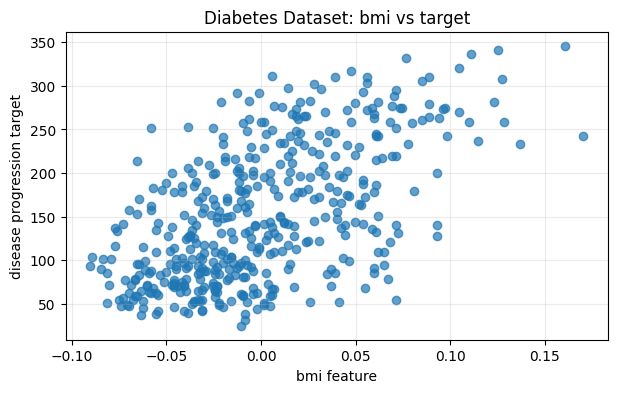

In [4]:
plt.scatter(X.ravel(), y, alpha=0.7)
plt.xlabel("bmi feature")
plt.ylabel("disease progression target")
plt.title("Diabetes Dataset: bmi vs target")
plt.grid(alpha=0.25)
plt.show()

## 5. 划分训练集、验证集、测试集

这次不用只划分 train/test，而是划分三份：

- 训练集：用来训练模型。
- 验证集：用来选择模型复杂度和参数。
- 测试集：最后只用一次，用来估计最终效果。

请你填写 `TEST_SIZE` 和 `VAL_SIZE`。

提示：可以先用 `TEST_SIZE = 0.2`，`VAL_SIZE = 0.25`。这里的 `VAL_SIZE=0.25` 是从剩下的 80% 中再切 25%，最终大约是 60% train、20% validation、20% test。

In [7]:
TEST_SIZE = 0.2  # TODO: 你来填，例如 0.2
VAL_SIZE = 0.25   # TODO: 你来填，例如 0.25

assert TEST_SIZE is not None, "请先填写 TEST_SIZE，例如 0.2"
assert VAL_SIZE is not None, "请先填写 VAL_SIZE，例如 0.25"

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=VAL_SIZE,
    random_state=42,
)

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape, y_val.shape)
print("test: ", X_test.shape, y_test.shape)

train: (264, 1) (264,)
val:   (89, 1) (89,)
test:  (89, 1) (89,)


## 6. 评估函数

为了重复比较多个模型，我们写一个统一的评估函数。

这次主要看：

- MSE：越低越好。
- RMSE：MSE 开方，单位更接近原始目标值。
- R2：越接近 1 越好，但小数据/弱特征时可能不高。

In [8]:
def evaluate_regression(model, X_data, y_data):
    pred = model.predict(X_data)
    mse = mean_squared_error(y_data, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_data, pred)
    return mse, rmse, r2


def print_metrics(name, model):
    train_mse, train_rmse, train_r2 = evaluate_regression(model, X_train, y_train)
    val_mse, val_rmse, val_r2 = evaluate_regression(model, X_val, y_val)
    test_mse, test_rmse, test_r2 = evaluate_regression(model, X_test, y_test)

    print(name)
    print(f"  train MSE={train_mse:.2f}, RMSE={train_rmse:.2f}, R2={train_r2:.3f}")
    print(f"  val   MSE={val_mse:.2f}, RMSE={val_rmse:.2f}, R2={val_r2:.3f}")
    print(f"  test  MSE={test_mse:.2f}, RMSE={test_rmse:.2f}, R2={test_r2:.3f}")

    return {
        "model": name,
        "train_mse": train_mse,
        "val_mse": val_mse,
        "test_mse": test_mse,
        "train_r2": train_r2,
        "val_r2": val_r2,
        "test_r2": test_r2,
    }

## 7. 先训练一个简单线性模型

这是 baseline。先用最简单的一条直线拟合数据。

In [9]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_result = print_metrics("Linear Regression", linear_model)

Linear Regression
  train MSE=4012.69, RMSE=63.35, R2=0.355
  val   MSE=3430.10, RMSE=58.57, R2=0.374
  test  MSE=4074.72, RMSE=63.83, R2=0.231


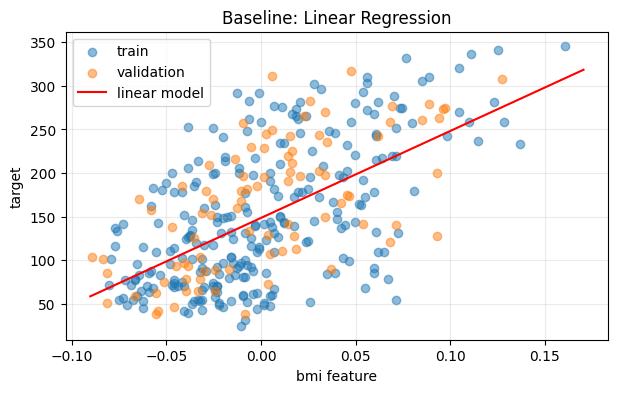

In [10]:
x_grid = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
linear_pred = linear_model.predict(x_grid)

plt.scatter(X_train.ravel(), y_train, alpha=0.5, label="train")
plt.scatter(X_val.ravel(), y_val, alpha=0.5, label="validation")
plt.plot(x_grid.ravel(), linear_pred, color="red", label="linear model")
plt.xlabel("bmi feature")
plt.ylabel("target")
plt.title("Baseline: Linear Regression")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 8. 多项式模型：观察欠拟合和过拟合

多项式特征可以让模型从直线变成曲线。

- degree 太低：模型太简单，可能欠拟合。
- degree 合适：能捕捉一部分非线性关系。
- degree 太高：可能在训练集上很好，但在验证集/测试集上变差，这就是过拟合。

你可以先运行默认列表，之后自己改 `DEGREES`。

In [11]:
DEGREES = [1, 3, 8, 15]

def make_polynomial_model(degree):
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        LinearRegression(),
    )


poly_results = []
poly_models = {}

for degree in DEGREES:
    model = make_polynomial_model(degree)
    model.fit(X_train, y_train)
    poly_models[degree] = model

    result = print_metrics(f"Polynomial degree={degree}", model)
    result["degree"] = degree
    poly_results.append(result)
    print()

Polynomial degree=1
  train MSE=4012.69, RMSE=63.35, R2=0.355
  val   MSE=3430.10, RMSE=58.57, R2=0.374
  test  MSE=4074.72, RMSE=63.83, R2=0.231

Polynomial degree=3
  train MSE=3982.23, RMSE=63.10, R2=0.359
  val   MSE=3540.81, RMSE=59.50, R2=0.354
  test  MSE=4100.57, RMSE=64.04, R2=0.226

Polynomial degree=8
  train MSE=3846.40, RMSE=62.02, R2=0.381
  val   MSE=3825.51, RMSE=61.85, R2=0.302
  test  MSE=11331.14, RMSE=106.45, R2=-1.139

Polynomial degree=15
  train MSE=3739.88, RMSE=61.15, R2=0.398
  val   MSE=110626.82, RMSE=332.61, R2=-19.192
  test  MSE=27193710.93, RMSE=5214.76, R2=-5131.679



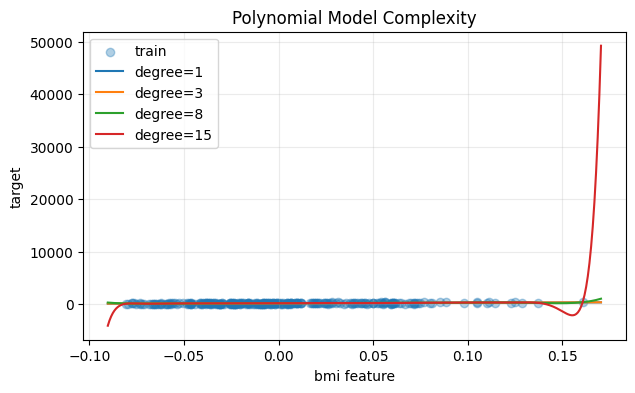

In [12]:
plt.scatter(X_train.ravel(), y_train, alpha=0.35, label="train")

for degree, model in poly_models.items():
    pred = model.predict(x_grid)
    plt.plot(x_grid.ravel(), pred, label=f"degree={degree}")

plt.xlabel("bmi feature")
plt.ylabel("target")
plt.title("Polynomial Model Complexity")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

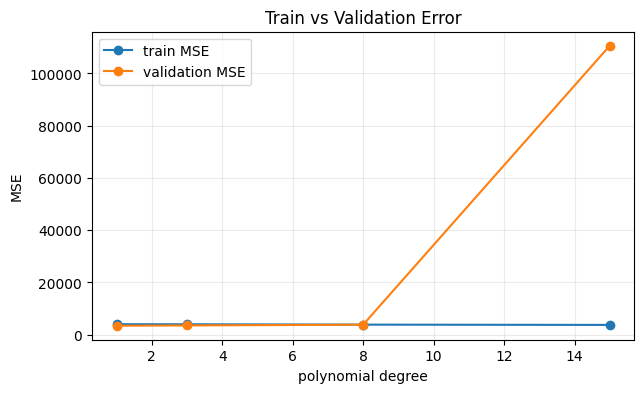

In [13]:
degrees = [r["degree"] for r in poly_results]
train_mse = [r["train_mse"] for r in poly_results]
val_mse = [r["val_mse"] for r in poly_results]

plt.plot(degrees, train_mse, marker="o", label="train MSE")
plt.plot(degrees, val_mse, marker="o", label="validation MSE")
plt.xlabel("polynomial degree")
plt.ylabel("MSE")
plt.title("Train vs Validation Error")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 9. 选择一个高复杂度模型，加入正则化

正则化的直觉：不要让模型参数变得太大，限制模型过度弯曲。

- Ridge：L2 正则化，会惩罚参数平方和。
- Lasso：L1 正则化，会让一部分参数变成 0，更像自动筛掉一些特征。

请你填写 `HIGH_DEGREE`、`RIDGE_ALPHA`、`LASSO_ALPHA`。

提示：可以先试：`HIGH_DEGREE = 15`，`RIDGE_ALPHA = 1.0`，`LASSO_ALPHA = 0.01`。

In [18]:
HIGH_DEGREE = 15   # TODO: 你来填，例如 15
RIDGE_ALPHA = 1.0   # TODO: 你来填，例如 1.0
LASSO_ALPHA = 0.05   # TODO: 你来填，例如 0.01

assert HIGH_DEGREE is not None, "请先填写 HIGH_DEGREE，例如 15"
assert RIDGE_ALPHA is not None, "请先填写 RIDGE_ALPHA，例如 1.0"
assert LASSO_ALPHA is not None, "请先填写 LASSO_ALPHA，例如 0.01"

unregularized_high_degree = make_pipeline(
    PolynomialFeatures(degree=HIGH_DEGREE, include_bias=False),
    StandardScaler(),
    LinearRegression(),
)

ridge_model = make_pipeline(
    PolynomialFeatures(degree=HIGH_DEGREE, include_bias=False),
    StandardScaler(),
    Ridge(alpha=RIDGE_ALPHA),
)

lasso_model = make_pipeline(
    PolynomialFeatures(degree=HIGH_DEGREE, include_bias=False),
    StandardScaler(),
    Lasso(alpha=LASSO_ALPHA, max_iter=100000),

)

models_to_compare = {
    "High degree no regularization": unregularized_high_degree,
    "Ridge regularization": ridge_model,
    "Lasso regularization": lasso_model,
}

regularization_results = []

for name, model in models_to_compare.items():
    model.fit(X_train, y_train)
    result = print_metrics(name, model)
    regularization_results.append(result)
    print()

High degree no regularization
  train MSE=3739.88, RMSE=61.15, R2=0.398
  val   MSE=110626.82, RMSE=332.61, R2=-19.192
  test  MSE=27193710.93, RMSE=5214.76, R2=-5131.679

Ridge regularization
  train MSE=3956.67, RMSE=62.90, R2=0.364
  val   MSE=3528.75, RMSE=59.40, R2=0.356
  test  MSE=6148.86, RMSE=78.41, R2=-0.161

Lasso regularization
  train MSE=3946.85, RMSE=62.82, R2=0.365
  val   MSE=3513.27, RMSE=59.27, R2=0.359
  test  MSE=7424.65, RMSE=86.17, R2=-0.401



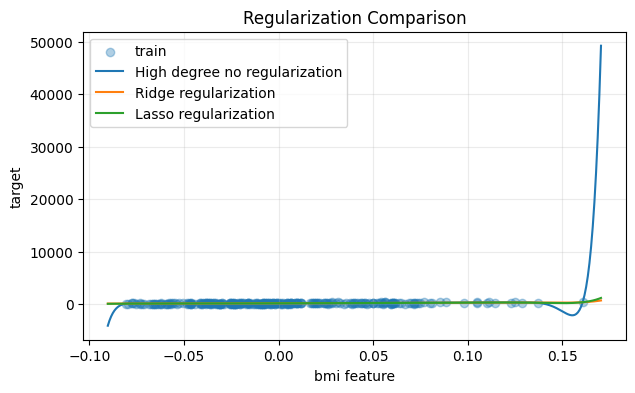

In [16]:
plt.scatter(X_train.ravel(), y_train, alpha=0.35, label="train")

for name, model in models_to_compare.items():
    pred = model.predict(x_grid)
    plt.plot(x_grid.ravel(), pred, label=name)

plt.xlabel("bmi feature")
plt.ylabel("target")
plt.title("Regularization Comparison")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 10. 稍微进阶：训练样本数量对过拟合的影响

下面这个小实验会逐步增加训练样本数量，观察训练误差和验证误差。

一般来说：

- 如果训练误差低、验证误差高，可能过拟合。
- 如果训练误差和验证误差都高，可能欠拟合。
- 如果数据更多后验证误差下降，说明增加数据可能有帮助。

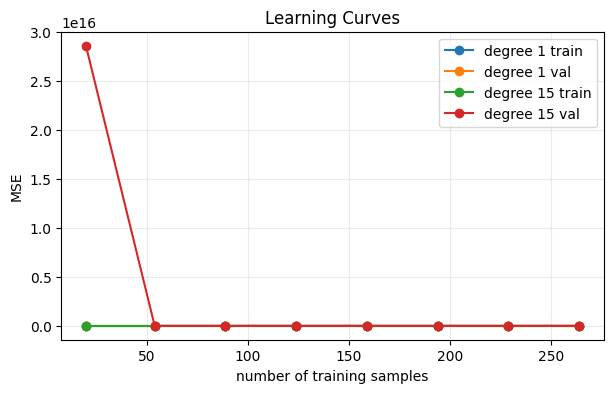

In [17]:
def learning_curve_for_model(model_factory, train_sizes):
    train_errors = []
    val_errors = []

    for size in train_sizes:
        X_subset = X_train[:size]
        y_subset = y_train[:size]

        model = model_factory()
        model.fit(X_subset, y_subset)

        train_mse, _, _ = evaluate_regression(model, X_subset, y_subset)
        val_mse, _, _ = evaluate_regression(model, X_val, y_val)

        train_errors.append(train_mse)
        val_errors.append(val_mse)

    return train_errors, val_errors


train_sizes = np.linspace(20, len(X_train), 8, dtype=int)

simple_train, simple_val = learning_curve_for_model(
    lambda: make_polynomial_model(1),
    train_sizes,
)

complex_train, complex_val = learning_curve_for_model(
    lambda: make_polynomial_model(HIGH_DEGREE),
    train_sizes,
)

plt.plot(train_sizes, simple_train, marker="o", label="degree 1 train")
plt.plot(train_sizes, simple_val, marker="o", label="degree 1 val")
plt.plot(train_sizes, complex_train, marker="o", label=f"degree {HIGH_DEGREE} train")
plt.plot(train_sizes, complex_val, marker="o", label=f"degree {HIGH_DEGREE} val")
plt.xlabel("number of training samples")
plt.ylabel("MSE")
plt.title("Learning Curves")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 11. 总结

请你完成下面的问题：

1. degree 很低时，训练误差和验证误差有什么特点？这更像欠拟合还是过拟合？
2. degree 很高时，训练误差是否一定会下降？验证误差是否也一定下降？
3. 为什么不能只看训练集 MSE？
4. Ridge 和 Lasso 加入后，曲线有什么变化？验证集 MSE 有没有改善？
5. 如果一个模型训练集很好、验证集很差，你会优先尝试哪些办法？

我的总结：

- degree 很低时，模型太简单，只能拟合很有限的关系。例如 degree=1 基本就是一条直线，如果真实数据关系不是严格线性的，就很难捕捉规律。因此训练误差和验证误差都可能较高，这更像欠拟合，也就是模型表达能力不足。
- degree 很高时，模型表达能力更强，训练误差通常会下降，但验证误差不一定下降。我的实验中 degree=15 的 train MSE 是 `3739.88`，比 degree=1 的 `4012.69` 更低，但 val MSE 升到 `110626.82`，test MSE 更是升到 `27193710.93`，说明高阶模型严重过拟合。
- 不能只看训练集 MSE，因为训练集是模型已经见过的数据。复杂模型可能把训练集中的噪声也记住，让训练集 MSE 变低，但对验证集和测试集表现很差。因此验证集 MSE 更适合用来选择模型复杂度，测试集 MSE 应该留到最后评估。
- 加入 Ridge 和 Lasso 后，高阶模型的曲线会比无正则化时更平滑，不容易剧烈波动。数值上，无正则化高阶模型 val MSE 是 `110626.82`；Ridge 降到 `3528.75`，Lasso 降到 `3513.27`，说明正则化明显改善了泛化能力。代价是训练集 MSE 略微升高，但这是合理的，因为模型不再过度贴合训练集。
- 如果训练集很好、验证集很差，通常说明模型过拟合。我会优先检查数据划分和数据泄漏，然后降低模型复杂度、加入或增强正则化、增加训练数据、清理异常值和错误标签、减少噪声特征，并用交叉验证获得更稳定的评估。对于神经网络，还可以使用 dropout、weight decay 和 early stopping。